In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path
from torchvision.datasets.utils import download_url
import graph_print_analysis as gp_tool
# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from environment.hilbert_distance import hilbert_analysis as hda
from train_mnist_with_hilbert import HBModel_MNIST as hbm


In [5]:
num_epochs = 2
lr = 1e-2
if_decay = True
batch_sizes = {16, 32, 64, 128, 256, 512, 1024}
batch_size=8192
steps = {200, 400, 800, 1200, 1600, 2000}
step=100
lrs={1e-4,1e-3, 1e-2, 1e-1}
decays={0, 1e-3, 1e-1}
if_regularize=True

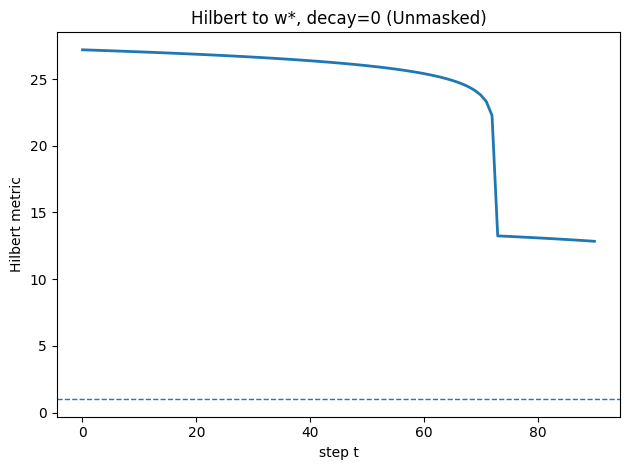

===== Hilbert Metric Statistics =====

The first 200 steps:
  Mean ≈ 23.5916
  Min ≈ 12.8395, Max ≈ 27.1914
  Q25 ≈ 24.4902, Q75 ≈ 26.8100

The 200 to 400 steps:
  No data available.

The last 200 steps:
  Mean ≈ 23.5916
  Min ≈ 12.8395, Max ≈ 27.1914
  Q25 ≈ 24.4902, Q75 ≈ 26.8100



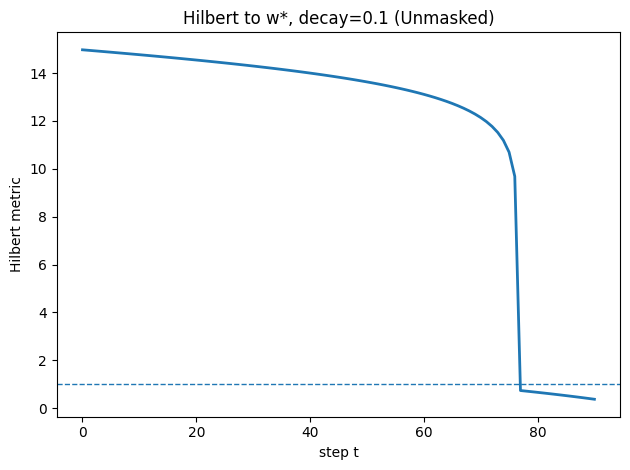

===== Hilbert Metric Statistics =====

The first 200 steps:
  Mean ≈ 11.7397
  Min ≈ 0.3707, Max ≈ 14.9714
  Q25 ≈ 12.4739, Q75 ≈ 14.4846

The 200 to 400 steps:
  No data available.

The last 200 steps:
  Mean ≈ 11.7397
  Min ≈ 0.3707, Max ≈ 14.9714
  Q25 ≈ 12.4739, Q75 ≈ 14.4846



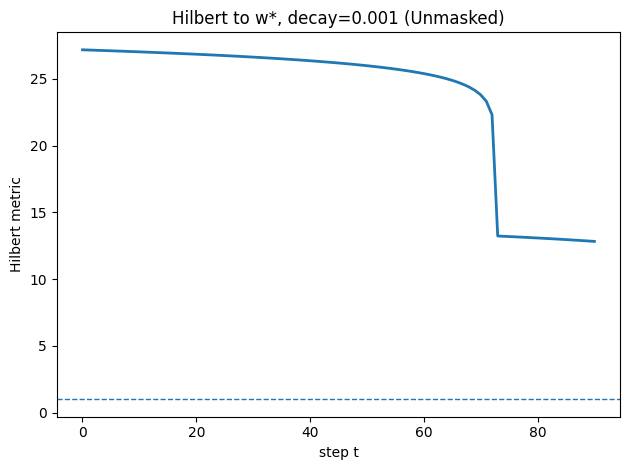

===== Hilbert Metric Statistics =====

The first 200 steps:
  Mean ≈ 23.5770
  Min ≈ 12.8235, Max ≈ 27.1751
  Q25 ≈ 24.4798, Q75 ≈ 26.7936

The 200 to 400 steps:
  No data available.

The last 200 steps:
  Mean ≈ 23.5770
  Min ≈ 12.8235, Max ≈ 27.1751
  Q25 ≈ 24.4798, Q75 ≈ 26.7936



In [27]:
unmasks={}
for decay in decays:
    res=hbm.train_with_optional_initialization(num_steps=100,
        sample_size=batch_size,
        lr=lr,
        if_decay=if_decay,
        number_of_layerss=15,
        if_initialize=True,regularization_coeff=decay,seed=1919810)
    trajec=res['param_traj']
    w_star=trajec[-1]
    trajec=trajec[:-10]
    analysis_result=gp_tool.analysis_to_w_star(trajectory=trajec, w_star=w_star, if_show=True, if_print=True, if_save=False, if_writes=True, plt_title=f"Hilbert to w*, decay={decay}", if_masked=False,if_smooth=False)
    unmasks[decay]=analysis_result

In [28]:
print(unmasks.keys())
trajehe3=unmasks[1e-3]
print(trajehe3)

dict_keys([0, 0.1, 0.001])
{'hilbert_to_w_star': [27.17510395286261, 27.160769423255687, 27.146239425938177, 27.13150845049077, 27.11657068380444, 27.101419991218982, 27.08605009535907, 27.07045436752039, 27.054625873414953, 27.03855735409376, 27.022241205357176, 27.00566945550667, 26.98883374127513, 26.971725281753685, 26.95433492585066, 26.93665289706164, 26.918668982019412, 26.900372420939135, 26.881751949371633, 26.862795513640517, 26.84349054628318, 26.823823585074404, 26.803780551312414, 26.783346345091445, 26.762505124961354, 26.7412398756101, 26.71953268678657, 26.697364386468514, 26.674714526732593, 26.65156116544354, 26.62788103967318, 26.60364912302167, 26.578838561355845, 26.553420490379583, 26.527363829859617, 26.500634991216216, 26.473197788845447, 26.445012966822443, 26.416037911742414, 26.3862261917395, 26.355527368016052, 26.323886075465737, 26.29124167514538, 26.257527479281357, 26.222669919007163, 26.186587563846928, 26.149189960079433, 26.110376334357774, 26.0700336

In [4]:
from matplotlib import pyplot as plt
